<a href="https://colab.research.google.com/github/Aatka-Saleem/ML-Core-Implementations/blob/main/06-Deep-Learning-%26--Neural-Networks/Artificial_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

from tensorflow.keras.utils import img_to_array, array_to_img, load_img
from keras.datasets import cifar10
#this dataset can also be downloaded from https://www.cs.toronto.edu/~kriz/cifar.html

from keras.models import Sequential
from keras.layers import Input, Dense, Activation

The following codes can be run in two ways:
1. Run on your local machine using anaconda.
   - To install TensorFlow2 and Keras on Anaconda, run the following commands on the shell:\
     conda install –c conda-forge tensorflow\
     conda install –c conda-forge keras
     
   - It can also be installed using pip as follows:\
     pip install --upgrade pip\
     pip install tensorflow
     
     
2. Run on Google Colaboratory (CoLab).
   - No installation required.
   - The images and data used in code has to be uploaded (in the files area) afresh everytime   CoLab is used.
   - One trick around is to place all the data and images in Google Drive and mount the drive in Google Colab as shown in the following code. This will save us from uploading the images again anad again everytime use use the notebook.
     

# Building an ANN Model

## Loading Data

- We will train our model on CIFAR-10 dataset.
- The CIFAR-10 dataset consists of 60000 32x32 color images in 10 classes, with 6000 images per class.
- There are 50000 training images and 10000 test images.
- The dataset can also be downloaded from
https://www.cs.toronto.edu/~kriz/cifar.html


In [ ]:
(x_train_org, y_train_org), (x_test_org, y_test_org) = cifar10.load_data() #org for original

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


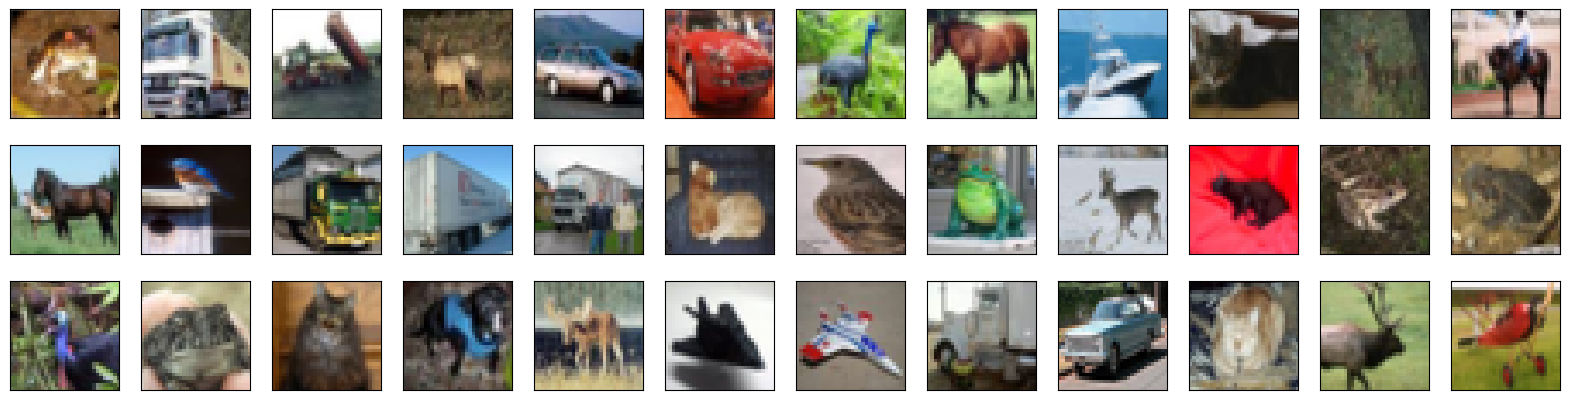

In [ ]:
fig = plt.figure(figsize=(20,5))
for i in range(36):
    ax = fig.add_subplot(3, 12, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(x_train_org[i]))

In [ ]:
type(x_train_org)

numpy.ndarray

## Exploring the Data

Categories in CIFAR10
- Category 0: airplane
- Category 1: automobile
- Category 2: bird
- Category 3: cat
- Category 4: deer
- Category 5: dog
- Category 6: frog
- Category 7: horse
- Category 8: ship
- Category 9: truck

In [ ]:
#Let us see the shape of the data container x_train_all that we have loaded
x_train_org.shape

(50000, 32, 32, 3)

In [ ]:
#Let us see how it looks like
x_train_org

array([[[[ 59,  62,  63],
         [ 43,  46,  45],
         [ 50,  48,  43],
         ...,
         [158, 132, 108],
         [152, 125, 102],
         [148, 124, 103]],

        [[ 16,  20,  20],
         [  0,   0,   0],
         [ 18,   8,   0],
         ...,
         [123,  88,  55],
         [119,  83,  50],
         [122,  87,  57]],

        [[ 25,  24,  21],
         [ 16,   7,   0],
         [ 49,  27,   8],
         ...,
         [118,  84,  50],
         [120,  84,  50],
         [109,  73,  42]],

        ...,

        [[208, 170,  96],
         [201, 153,  34],
         [198, 161,  26],
         ...,
         [160, 133,  70],
         [ 56,  31,   7],
         [ 53,  34,  20]],

        [[180, 139,  96],
         [173, 123,  42],
         [186, 144,  30],
         ...,
         [184, 148,  94],
         [ 97,  62,  34],
         [ 83,  53,  34]],

        [[177, 144, 116],
         [168, 129,  94],
         [179, 142,  87],
         ...,
         [216, 184, 140],
        

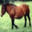

In [ ]:
##Let us display the image after converting from array to image
pic = array_to_img(x_train_org[7])
display(pic)

In [ ]:
#Now let us see the shape of y_train_all
y_train_org.shape
#it contains the class number for the object

(50000, 1)

In [ ]:
#Let us see how y_train looks like
y_train_org

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [ ]:
#Let us see the object class number for the horse shown above
y_train_org[7][0]
#You can see the categories listed in a previous cell that category 7 is 'horse'.

np.uint8(7)

In [ ]:
#Since remembering all category numbers and their corresponding names is difficult,
#let us create labels names list for our own convenience:
LABEL_NAMES = ['Plane', 'Car', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']
#Testing our logic
LABEL_NAMES[y_train_org[7][0]]

'Horse'

## Preprocessing Data

### Scaling and flattening the train data

In [ ]:
#Scaling the training data between 0 and 1
x_train_scaled = x_train_org / 255.0

In [ ]:
#Let us see the data again after scaling.
x_train_scaled
#note that this is a 4D tensor.

array([[[[0.23137255, 0.24313725, 0.24705882],
         [0.16862745, 0.18039216, 0.17647059],
         [0.19607843, 0.18823529, 0.16862745],
         ...,
         [0.61960784, 0.51764706, 0.42352941],
         [0.59607843, 0.49019608, 0.4       ],
         [0.58039216, 0.48627451, 0.40392157]],

        [[0.0627451 , 0.07843137, 0.07843137],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509804, 0.21568627],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117647, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215686, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941176, 0.19607843],
         [0.47058824, 0.32941176, 0.19607843],
         [0.42745098, 0.28627451, 0.16470588]],

        ...,

        [[0.81568627, 0.66666667, 0.37647059],
         [0.78823529, 0.6       , 0.13333333]

In [ ]:
#Flattening the train tensor; placing all pixel for one image in one dimension
TOTAL_INPUTS=32*32*3 #=3072
x_train_scaled_flat = x_train_scaled.reshape(x_train_scaled.shape[0], TOTAL_INPUTS)

In [ ]:
#Let us see how this flat array looks like
x_train_scaled_flat
#Now it is a 2D tensor.

array([[0.23137255, 0.24313725, 0.24705882, ..., 0.48235294, 0.36078431,
        0.28235294],
       [0.60392157, 0.69411765, 0.73333333, ..., 0.56078431, 0.52156863,
        0.56470588],
       [1.        , 1.        , 1.        , ..., 0.31372549, 0.3372549 ,
        0.32941176],
       ...,
       [0.1372549 , 0.69803922, 0.92156863, ..., 0.04705882, 0.12156863,
        0.19607843],
       [0.74117647, 0.82745098, 0.94117647, ..., 0.76470588, 0.74509804,
        0.67058824],
       [0.89803922, 0.89803922, 0.9372549 , ..., 0.63921569, 0.63921569,
        0.63137255]])

In [ ]:
x_train_scaled_flat.shape
#Note that 3072 = 32 x 32 x 3

(50000, 3072)

### Scaling and flattening the test data

In [ ]:
#Scaling the test tensor between 0 and 1.
x_test_scaled = x_test_org / 255.0

In [ ]:
#Flattening the test tensor; placing all pixel for one image in one dimension
x_test_scaled_flat = x_test_scaled.reshape(x_test_scaled.shape[0], TOTAL_INPUTS)
x_test_scaled_flat

array([[0.61960784, 0.43921569, 0.19215686, ..., 0.08235294, 0.2627451 ,
        0.43137255],
       [0.92156863, 0.92156863, 0.92156863, ..., 0.72941176, 0.78431373,
        0.78039216],
       [0.61960784, 0.74509804, 0.87058824, ..., 0.02745098, 0.03137255,
        0.02745098],
       ...,
       [0.07843137, 0.05882353, 0.04705882, ..., 0.09803922, 0.07843137,
        0.18431373],
       [0.09803922, 0.15686275, 0.04705882, ..., 0.36078431, 0.47058824,
        0.31372549],
       [0.28627451, 0.30588235, 0.29411765, ..., 0.10588235, 0.10196078,
        0.10196078]])

In [ ]:
#x_test
x_test_scaled_flat.shape

(10000, 3072)

In [ ]:
#Renaming x_test_scaled_flat to simply x_test for easier use later.
x_test = x_test_scaled_flat
#Renaming y_test_org to simply y_test for easier use later.
y_test=y_test_org

### Creating Validation Dataset
Since the dataset is pretty large, let us make a third set also; by dividing the trainset further into train and validation sets.

In [ ]:
VALIDATION_SIZE=10000

##Creating validation set
x_val = x_train_scaled_flat[:VALIDATION_SIZE]
y_val = y_train_org[:VALIDATION_SIZE]
x_val.shape

(10000, 3072)

In [ ]:
##Creating the remaining train set
x_train = x_train_scaled_flat[VALIDATION_SIZE:]
y_train = y_train_org[VALIDATION_SIZE:]
x_train.shape

(40000, 3072)

So now we have three scaled and flattened datasets:
- The train set (x_train,y_train) having 40000 samples
- The validation set (x_val,y_val) having 10000 samples
- The test set (x_test,y_test) having 10000 samples

## Define the Neural Network using Keras

In [ ]:
#Defining the model
model = Sequential([
    Input(shape=(TOTAL_INPUTS,)),
    Dense(units=128, activation='relu', name='m1_hidden1'),
    Dense(units=64, activation='relu', name='m1_hidden2'),
    Dense(16, activation='relu', name='m1_hidden3'),
    Dense(10, activation='softmax', name='m1_output')
])
#if we donot give names to the layers, then the names keep on changing on every run

In [ ]:
type(model)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ m1_hidden1 (Dense)              │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ m1_hidden2 (Dense)              │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ m1_hidden3 (Dense)              │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ m1_output (Dense)               │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,810 (1.54 MB)

 Trainable params: 402,810 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

- TOTAL_INPUTS=32 x 32 x 3=3072
- Total neurons in layer m1_hidden1 = (TOTAL_INPUTS+1)*128   ;+1 for the additional bias node
- Total neurons in layer m1_hidden2 = (128+1)*64  
- Total neurons in layer m1_hidden3 = (64+1)*16
- Total neurons in layer m1_output = (16+1)*10

In [ ]:
#Compiling the model
model.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

## Fitting the Model

In [ ]:
#Setting some hyperparameters
batch_size = 1000
nr_epochs = 150

In [ ]:
%%time
history=model.fit(x_train, y_train, batch_size=batch_size, epochs=nr_epochs, verbose=0, validation_data=(x_val, y_val))

CPU times: user 1min 17s, sys: 16.2 s, total: 1min 33s
Wall time: 1min 19s


### Some points to remember:

- Models starts training from the point where it left last time. To avoid this, compile the model afresh.

- On different runs, the optimiser may start from a different point (different initial values of the weights), hence generating a different graphs each time.

## Plotting the Learning Curves

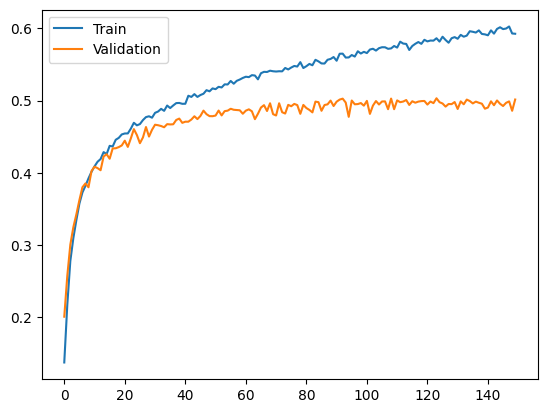

In [ ]:
#Plotting the learning curves for train and test accuracy
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.show()

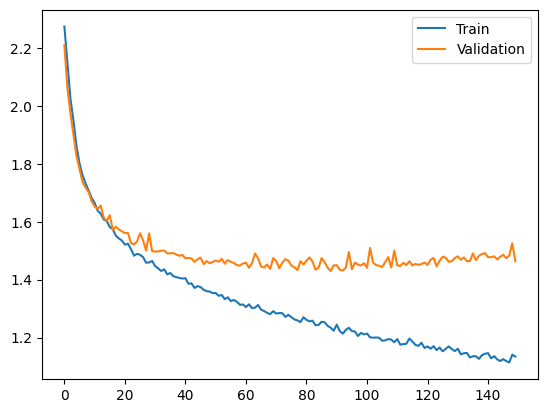

In [ ]:
#Plotting the learning curves for train and test loss
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.show()

## Making Predictions on Individual Images

In [ ]:
image_nr=0
x_val[image_nr].shape

(3072,)

In [ ]:
##Adding a dimension as per requirement of predict method
test = np.expand_dims(x_val[image_nr], axis=0)
test.shape

(1, 3072)

In [ ]:
model.predict(test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step


array([[4.2568753e-03, 1.6217165e-03, 3.7135214e-02, 1.4370890e-01,
        1.7107429e-02, 7.1346998e-02, 7.0183748e-01, 2.2392830e-02,
        3.9897361e-04, 1.9352275e-04]], dtype=float32)

- Since the metric set while compiling the model was 'accuracy', so these 10 values given above in the output in the array are accuracy values for each of the 10 classes.
- In such cases the prediction is made on the class having the highest accuracy.
- The following code picks the highest probability class for us.

In [ ]:
#Picking the highest probability class
predicted_value=np.argmax(model.predict(test), axis=1)
actual_value=y_val[image_nr]
print(f'Actual value: {LABEL_NAMES[actual_value[0]]} vs. predicted: {LABEL_NAMES[predicted_value[0]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Actual value: Frog vs. predicted: Frog


## Evaluation
- Now let us evaluate the model for the test dataset that we initially kept aside.

In [ ]:
#Recalling the metrics that we set during compilation of the model.
model.metrics_names

['loss', 'compile_metrics']

In [ ]:
# Let us print the loss funcstion value and overall accuracy of our model on test data.
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f'Test loss is {test_loss:0.3} and test accuracy is {test_accuracy:0.1%}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4887 - loss: 1.4824
Test loss is 1.48 and test accuracy is 48.9%


### Confusion Matrix
- Now let us print the confusion matrix and find recall and precision values by using the formulas that we studied in class previously.

In [ ]:
predictions=np.argmax(model.predict(x_test), axis=1)
conf_matrix = confusion_matrix(y_true=y_test, y_pred=predictions)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
conf_matrix

array([[497,  34,  61,  26,  38,  20,  22,  30, 211,  61],
       [ 43, 532,  27,  18,  15,  20,  18,  23, 117, 187],
       [ 71,  17, 381,  66, 143,  83, 110,  71,  33,  25],
       [ 29,  21, 107, 272,  73, 200, 156,  55,  38,  49],
       [ 40,   6, 152,  48, 440,  57, 117,  79,  43,  18],
       [ 19,  11,  91, 199,  79, 396,  82,  58,  35,  30],
       [ 10,  15,  79,  73, 111,  51, 597,  21,  23,  20],
       [ 50,  13,  60,  62, 108,  83,  35, 507,  27,  55],
       [ 81,  44,  15,  28,  20,  29,   9,   7, 710,  57],
       [ 35, 149,  24,  29,  15,  17,  24,  41, 111, 555]])

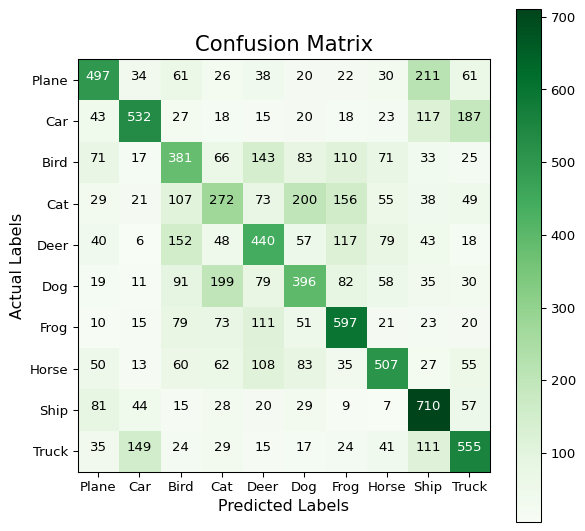

In [ ]:
# displaying confustion matrix
plt.figure(figsize=(7,7), dpi=95)
plt.imshow(conf_matrix, cmap=plt.cm.Greens)

plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('Actual Labels', fontsize=12)
plt.xlabel('Predicted Labels', fontsize=12)

tick_marks = np.arange(10)
plt.yticks(tick_marks, LABEL_NAMES)
plt.xticks(tick_marks, LABEL_NAMES)

plt.colorbar()

for i in range(10):
    for j in range(10):
        plt.text(j, i, conf_matrix[i, j], horizontalalignment='center',
                 color='white' if conf_matrix[i, j] > conf_matrix.max()/2 else 'black')

plt.show()

In [ ]:
recall = np.diag(conf_matrix) / np.sum(conf_matrix, axis=1)
recall

array([0.497, 0.532, 0.381, 0.272, 0.44 , 0.396, 0.597, 0.507, 0.71 ,
       0.555])

In [ ]:
avg_recall = np.mean(recall)
print(f'Model 1 recall score is {avg_recall:.2%}')

Model 1 recall score is 48.87%


In [ ]:
precision = np.diag(conf_matrix) / np.sum(conf_matrix, axis=0)
precision

array([0.568     , 0.63182898, 0.38214644, 0.33130329, 0.42226488,
       0.41422594, 0.51025641, 0.56838565, 0.52670623, 0.52507096])

In [ ]:
avg_precision = np.mean(precision)
print(f'Model 1 precision score is {avg_precision:.2%}')

f1_score = 2 * (avg_precision * avg_recall) / (avg_precision + avg_recall)
print(f'Model 1 f1 score is {f1_score:.2%}')

Model 1 precision score is 48.80%
Model 1 f1 score is 48.84%
